<a href="https://colab.research.google.com/github/sonasahakyan11/Online-Retail-Analysis/blob/main/Online_Retail_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Online Retail Analysis**

**Project Goal:** Explore UK Online Retail dataset to generate business insights on revenue, customers, and top products.

### **Import Libraries**

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Load Data**

In [59]:
from google.colab import drive

# mount Google Drive
drive.mount('/content/drive')

# read Excel file
df = pd.read_excel('/content/drive/MyDrive/DataProjects/OnlineRetail/data/online_retail_II.xlsx')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### **EDA (Exploratory Data Analysis)**

#### **Initial Cleaning & Revenue calculation**

#### **Data Inspection:**
Before cleaning, we inspect the dataset to understand its structure, missing and duplicate values, and basic statistics.

Quick data inspection

In [60]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


### **Initial Data Cleaning**

In [61]:
# Check for missing values
df.isnull().sum()

# Drop missing Customer IDs
df.dropna(subset=["Customer ID"], inplace=True)

# Check for dublicated data
df.duplicated().sum()

# Drop duplicate rows
df = df.drop_duplicates()

# Check for negative quantities
df[df['Quantity'] < 0]

# Remove returned items (negative quantity)
df = df[df['Quantity'] > 0]

# Calculate Revenue
df['Revenue'] = df['Quantity'] * df['Price']

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 400947 entries, 0 to 525460
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      400947 non-null  object        
 1   StockCode    400947 non-null  object        
 2   Description  400947 non-null  object        
 3   Quantity     400947 non-null  int64         
 4   InvoiceDate  400947 non-null  datetime64[ns]
 5   Price        400947 non-null  float64       
 6   Customer ID  400947 non-null  float64       
 7   Country      400947 non-null  object        
 8   Revenue      400947 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.6+ MB


*"Returned items (negative Quantity) were removed from revenue calculations for clarity. Net revenue including returns can also be analyzed separately if needed."*

## ***Exploratory Data Analysis (EDA) & Insights:***

**Covers:**

-   Revenue by Country
-   Top Products by Revenue
-   Monthly Revenue Trends
-   Customer Analysis: Top Customers & Repeat Buyers
-   Top Products by Revenue vs Quantity

### **Revenue by Country**

**Research Question**

**Problem:** Which countries contribute most to total revenue?

**Goal:** Identify key markets for sales, marketing, and inventory planning.

In [62]:
# Sum revenue for each country and sort countries by revenue (highest first)
df_grouped_on_country = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

# Select top 10 countries by revenue
top10_countries = df_grouped_on_country.head(10)

top10_countries

,Revenue
Country,
United Kingdom,7381644.433
EIRE,356041.860
Netherlands,268784.350
Germany,202025.391
France,146107.070
Sweden,53147.990
Denmark,50906.850
Spain,47568.650
Switzerland,43921.390


#### Visualisation (bar chart)

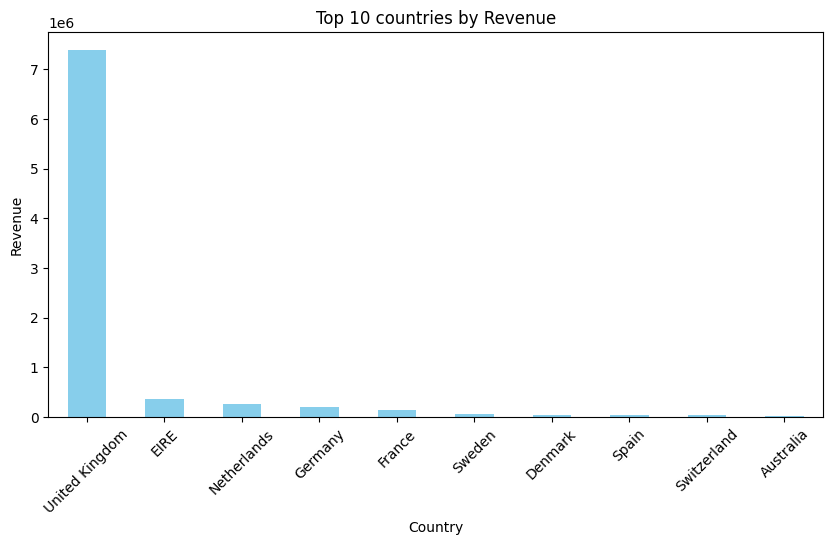

In [63]:
# Create a bar chart for top 10 countries by revenue
top10_countries.plot(kind='bar', figsize=(10, 5), color='skyblue')

plt.title("Top 10 countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

# Rotate country names for better readability
plt.xticks(rotation=45)

plt.show()

### **Observation:**

United Kingdom generates the highest revenue by a significant margin.

Other countries such as EIRE, Netherlands, Germany, and France contribute significantly less.

Most revenue comes from a few key markets, with the majority coming from the UK.

### **Top Products by Revenue**

**Problem:** Which products generate the most revenue?

**Goal:** Identify the top products by total revenue to understand which items contribute most to the business income.


In [64]:
# Sum revenue for each product and sort from highest to lowest
df_grouped_on_product = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False)

# Select top 10 products by revenue
top10_products = df_grouped_on_product.head(10)

top10_products

,Revenue
Description,
WHITE HANGING HEART T-LIGHT HOLDER,151339.16
REGENCY CAKESTAND 3 TIER,143727.60
Manual,98531.99
ASSORTED COLOUR BIRD ORNAMENT,70291.03
JUMBO BAG RED RETROSPOT,51644.25
POSTAGE,48741.08
ROTATING SILVER ANGELS T-LIGHT HLDR,40156.05
PAPER CHAIN KIT 50'S CHRISTMAS,36871.55
PARTY BUNTING,35017.30


#### Visualisation (bar chart)

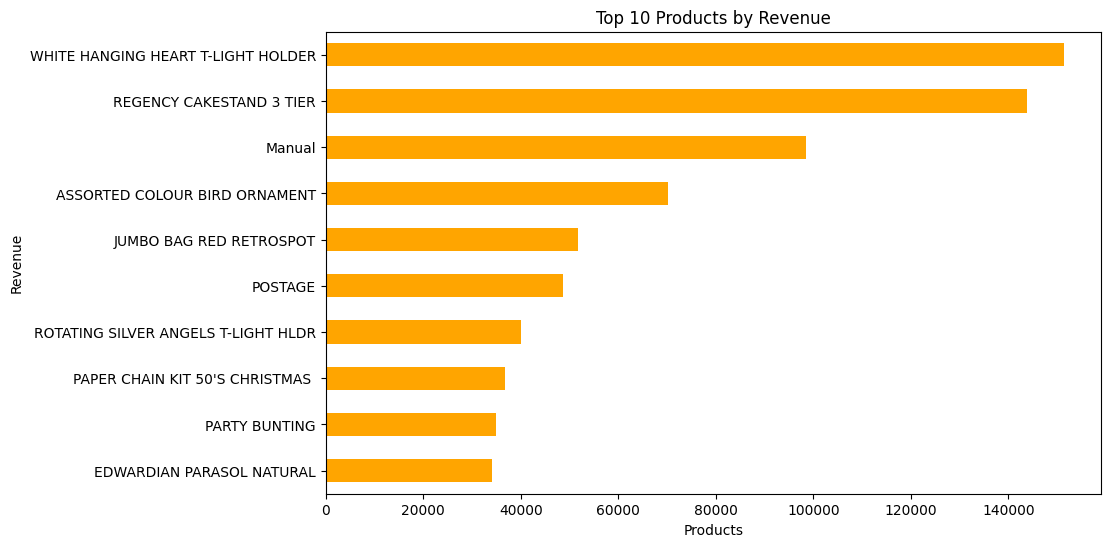

In [65]:
# Create a horizontal bar chart for top 10 products by revenue
top10_products.plot(kind='barh', figsize=(10,6), color='orange')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Products')
plt.ylabel('Revenue')

# Show highest revenue product at the top
plt.gca().invert_yaxis()
plt.show()

**Observation:**

The top 10 products generate a significant portion of total revenue.

Products like WHITE HANGING HEART T-LIGHT HOLDER and REGENCY CAKESTAND 3 TIER contribute the most, showing that a few key items drive the majority of sales.

### **Monthly Revenue Trends**

#### **Research Question**

**Problem:** How does revenue change over time?

**Goal:** We want to identify trends, seasonal patterns, and potential sales spikes throughout the year.

In [66]:
# Extract year-month from InvoiceDate
df['Month'] = df['InvoiceDate'].dt.to_period('M')

# Total revenue per month
monthly_revenue = df.groupby('Month')['Revenue'].sum()
monthly_revenue


,Revenue
Month,
2009-12,683504.010
2010-01,555802.672
2010-02,504558.956
2010-03,696978.471
2010-04,591982.002
2010-05,597833.380
2010-06,636371.130
2010-07,589736.170
2010-08,602224.600


#### *Visualisation (line chart)*

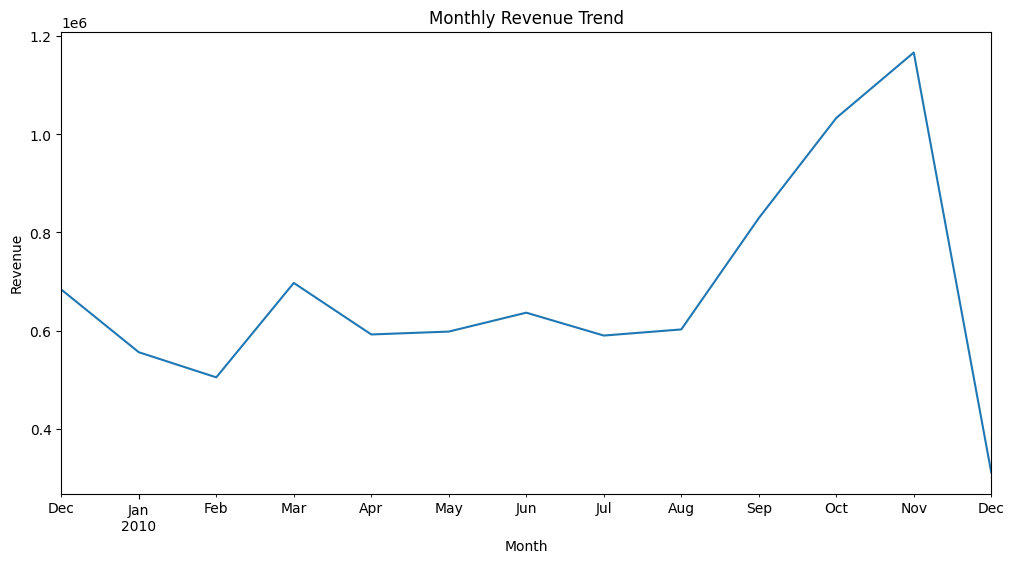

In [67]:
# Plot monthly revenue trend
monthly_revenue.plot(figsize=(12,6))
plt.title("Monthly Revenue Trend")
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

#### **Observation:**

Revenue fluctuates throughout the year, with noticeable peaks in November.

There is a significant increase toward the end of the year, which likely corresponds to the holiday shopping season.

This suggests that the retail business experiences strong seasonal demand.

### **Customer Analysis: Top Customers & Repeat Buyers**

#### **Research Question**

**Problem:** Which customers generate the most revenue?

**Goal:** Understand revenue concentration, identify high-value customers

In [68]:
# Total revenue per customer
customer_revenue = df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
top10_customers = customer_revenue.head(10)
top10_customers

,Revenue
Customer ID,
18102.0,349164.35
14646.0,248396.50
14156.0,196549.74
14911.0,152121.22
13694.0,131443.19
17511.0,84541.17
15061.0,83284.38
16684.0,80489.21
16754.0,65500.07


#### *Visualisation (barh chart)*

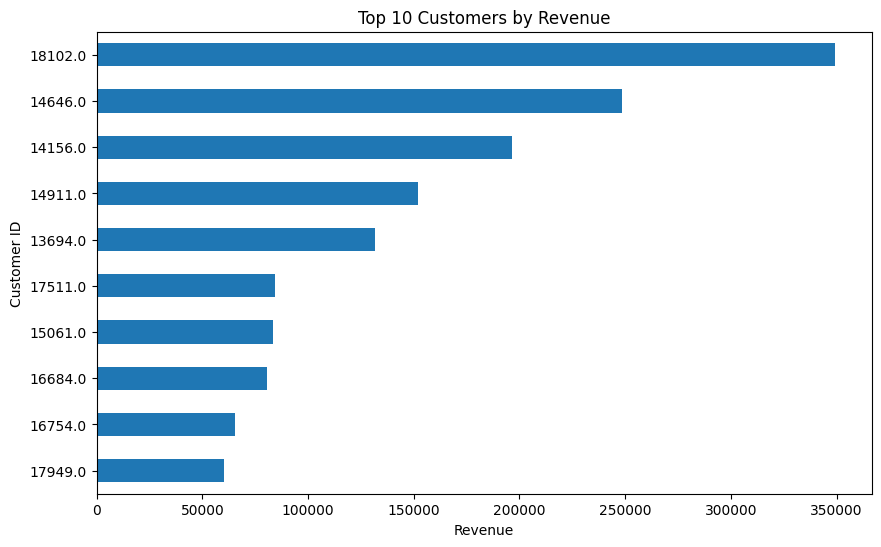

In [69]:
# Create a horizontal bar chart for top 10 customers by revenue
top10_customers.plot(kind='barh', figsize=(10,6))

plt.title("Top 10 Customers by Revenue")
plt.xlabel('Revenue')
plt.ylabel('Customer ID')

# Show the highest revenue customer at the top
plt.gca().invert_yaxis()

plt.show()

#### *Revenue concentration*

In [70]:
# Number of customers that make up 20% of all customers
customer_num_for_20percent = int((len(customer_revenue) * 20) /100)
print(f"20% of customers: {customer_num_for_20percent}")

# Total revenue
total_revenue = df['Revenue'].sum()
print(f"Total revenue: {total_revenue: .2f}")

# Revenue contributed by top 20 customers
top20_customer_revenue = customer_revenue.head(20).sum()

# Calculate percentage of total revenue contributed by top 20 customers
concentration_percent = (top20_customer_revenue / total_revenue) * 100
print(f"The top 20 customers contribute {concentration_percent:.2f}% of total revenue")

20% of customers: 862
Total revenue:  8798233.74
The top 20 customers contribute 21.90% of total revenue


#### **Observation:**

A small number of customers contribute a significant portion of the total revenue.

The top customers generate substantially higher revenue compared to others, indicating that the business relies heavily on high-value customers.

*A small portion of customers (top 20) contribute a significant percentage of total revenue, demonstrating strong revenue concentration consistent with the Pareto principle.*

### **Top Products by Revenue vs Quantity**

#### **Research Question**

**Problem:** Which products generate the most revenue, and how does that compare to the number of units sold?

**Goal:** Identify high-value vs high-volume products, inform pricing, inventory, and marketing strategies.

In [71]:
# Aggregate total quantity and revenue for each product, then sort by revenue
product_summary = df.groupby('Description').agg({
    "Quantity": "sum",
    "Revenue": "sum"
}).sort_values(by="Revenue", ascending=False)

top10_products = product_summary.head(10)
top10_products

,Quantity,Revenue
Description,,
WHITE HANGING HEART T-LIGHT HOLDER,56814,151339.16
REGENCY CAKESTAND 3 TIER,12489,143727.60
Manual,2569,98531.99
ASSORTED COLOUR BIRD ORNAMENT,44431,70291.03
JUMBO BAG RED RETROSPOT,29519,51644.25
POSTAGE,2212,48741.08
ROTATING SILVER ANGELS T-LIGHT HLDR,21579,40156.05
PAPER CHAIN KIT 50'S CHRISTMAS,13839,36871.55
PARTY BUNTING,8312,35017.30


#### *Visualisation, Plotting Quantity vs Revenue*

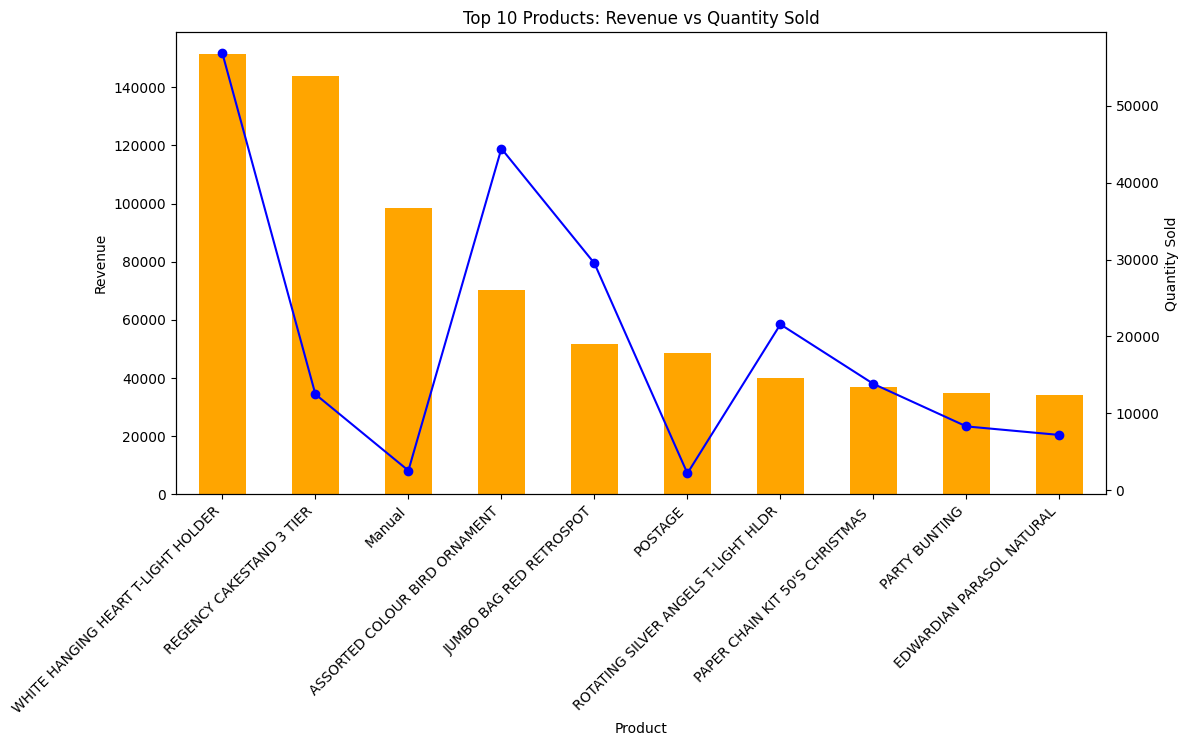

In [72]:
# Create figure and first axis (Revenue)
fig, ax1 = plt.subplots(figsize=(12,6))

# Plot Revenue as bars
top10_products['Revenue'].plot(kind='bar', color='orange', ax=ax1)
ax1.set_xlabel('Product')
ax1.set_ylabel('Revenue')
ax1.set_xticklabels(top10_products.index, rotation=45, ha='right')

# Create a second y-axis sharing the same x-axis for Quantity Sold
ax2 = ax1.twinx()

# Plot Quantity Sold as a line chart with markers on the second y-axis
top10_products['Quantity'].plot(kind='line', marker='o', color='blue', ax=ax2)
ax2.set_ylabel("Quantity Sold")

plt.title("Top 10 Products: Revenue vs Quantity Sold")
plt.show()

#### **Observation:**

The top-selling products by revenue do not always correspond to the products with the highest quantity sold.

Some products generate high revenue despite moderate sales volume, indicating higher prices or premium items.

This analysis highlights the difference between high-value products and high-volume products, which is useful for pricing, inventory management, and marketing strategies.

### **Final Summary / Conclusions**

1. Revenue by Country

United Kingdom generates the highest revenue by a significant margin.

Other countries, including EIRE, Netherlands, Germany, and France, contribute much less revenue compared to the United Kingdom.

Most revenue comes from a few key markets, with the majority coming from the UK.

2. Monthly Revenue Trend

Revenue fluctuates throughout the year, with noticeable peaks in November.

There is a significant increase toward the end of the year, likely corresponding to the holiday shopping season.

This suggests that the retail business experiences strong seasonal demand.

3. Customer Revenue / Revenue Concentration

A small number of customers contribute a significant portion of the total revenue.

The top customers generate substantially higher revenue compared to others, indicating that the business relies heavily on high-value customers.

This pattern is consistent with the 80/20 rule (Pareto principle), common in retail businesses.

4. Top Products by Revenue vs Quantity

The top-selling products by revenue do not always correspond to the products with the highest quantity sold.

Some products generate high revenue despite moderate sales volume, indicating higher prices or premium items.

This highlights the difference between high-value products and high-volume products, useful for pricing, inventory management, and marketing strategies.